In [23]:
"""
Amazon Product Recommendation System
- NetworkX Bipartite Graph  (User <-> Product)
- FAISS for product embedding similarity
- Mistral for recommendation explanation
"""

import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
import faiss
import ollama
import pickle
import re
from pathlib import Path
from langchain_ollama import ChatOllama
from collections import defaultdict

In [24]:
# ── Config ─────────────────────────────────────────────────────────────────────
DATA_PATH   = "/Users/mahalingaprabhu/Downloads/7817_1.csv"
OUTPUT_DIR  = Path("recsys_output")
OUTPUT_DIR.mkdir(exist_ok=True)

LLM_MODEL   = "mistral"
EMBED_MODEL  = "nomic-embed-text"
MIN_RATING   = 4      # only "liked" edges (rating >= 4)
MIN_REVIEWS  = 2      # user must have reviewed at least N products
TOP_K        = 5      # recommendations to return

llm = ChatOllama(model=LLM_MODEL, temperature=0)

In [25]:
# ── 1. Load & Clean ────────────────────────────────────────────────────────────

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, on_bad_lines="skip")

    df.rename(columns={
        "reviews.rating":   "rating",
        "reviews.username": "username",
        "reviews.text":     "review_text",
    }, inplace=True)

    df = df[["id", "name", "brand", "categories", "rating", "username", "review_text"]].copy()
    df.dropna(subset=["name", "username", "rating"], inplace=True)

    df["rating"]   = pd.to_numeric(df["rating"], errors="coerce")
    df["username"] = df["username"].str.strip().str.lower()
    df["name"]     = df["name"].str.strip()
    df["brand"]    = df["brand"].fillna("Unknown").str.strip()
    df.dropna(subset=["rating"], inplace=True)

    # Keep users with at least MIN_REVIEWS reviews — sparse users are noise
    user_counts = df["username"].value_counts()
    active_users = user_counts[user_counts >= MIN_REVIEWS].index
    df = df[df["username"].isin(active_users)]

    print(f"[load] {len(df)} interactions | "
          f"{df['username'].nunique()} users | "
          f"{df['name'].nunique()} products")
    return df


In [97]:
print("=== Step 1: Load Data ===")
df = load_data(DATA_PATH)
# products = df["name"].unique() #Product name
# products
df

=== Step 1: Load Data ===
[load] 437 interactions | 91 users | 58 products


,id,name,brand,categories,rating,username,review_text
49,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",4.0,matthew coenen,"I'm a first-time Kindle owner, so I have nothi..."
50,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",5.0,ron cronovich,UPDATE NOVEMBER 2011:My review is now over a y...
51,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",3.0,jeffrey stanley,The Kindle is my first e-ink reader. I own an ...
52,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",3.0,jeffrey stanley,The Kindle is my first e-ink reader. I own an ...
53,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",4.0,matthew coenen,"I'm a first-time Kindle owner, so I have nothi..."
...,...,...,...,...,...,...,...
1560,AVpge-anilAPnD_xtDVf,Amazon Premium Headphones,Amazon,"Amazon Devices,Corded Headsets,Electronics Fea...",5.0,andrew,"I bought these for a couple of reasons.First, ..."
1583,AVpfODXeilAPnD_xXeUd,Replacement Remote for Amazon Fire TV Stick,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",1.0,amazon customer,"Remote didn't work, did all the troubleshootin..."
1587,AVpfo9ukilAPnD_xfhuj,Alexa Voice Remote for Amazon Fire TV and Fire...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",2.0,amazon customer,I am now having to order my third remote becau...
1593,AVpfo9ukilAPnD_xfhuj,Alexa Voice Remote for Amazon Fire TV and Fire...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",1.0,amazon customer,I have had to change the batteries in this rem...


In [26]:
# ── 2. Build Bipartite Graph ───────────────────────────────────────────────────

def build_bipartite_graph(df: pd.DataFrame) -> nx.Graph:
    """
    Bipartite graph: User nodes (bipartite=0) <-> Product nodes (bipartite=1)
    Edge weight = rating (1-5)
    Only edges where rating >= MIN_RATING ("liked")
    """
    B = nx.Graph()

    # Add user nodes
    users = df["username"].unique()
    B.add_nodes_from(users, bipartite=0, node_type="user")

    # Add product nodes — use product name as ID (deduplicated)
    products = df["name"].unique() #Product name
    B.add_nodes_from(products, bipartite=1, node_type="product")

    # Add edges for liked interactions only
    liked = df[df["rating"] >= MIN_RATING]
    for _, row in liked.iterrows():
        user    = row["username"]
        product = row["name"]
        rating  = row["rating"]

        if B.has_edge(user, product):
            # If same user reviewed same product twice, take max rating
            B[user][product]["weight"] = max(B[user][product]["weight"], rating)
        else:
            B.add_edge(user, product,
                weight   = rating,
                edge_type = "LIKED"
            )

    # Attach product metadata to product nodes
    product_meta = (
        df.groupby("name")
          .agg(
              brand      = ("brand", "first"),
              category   = ("categories", "first"),
              avg_rating = ("rating", "mean"),
              num_reviews= ("rating", "count"),
              sample_review = ("review_text", "first"),
          )
          .reset_index()
    )
    for _, row in product_meta.iterrows():
        if row["name"] in B:
            B.nodes[row["name"]].update({
                "brand":       row["brand"],
                "category":    row["category"],
                "avg_rating":  round(row["avg_rating"], 2),
                "num_reviews": row["num_reviews"],
                "sample_review": str(row["sample_review"])[:300],
            })

    user_nodes    = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 0]
    product_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 1]

    print(f"[graph] User nodes    : {len(user_nodes)}")
    print(f"[graph] Product nodes : {len(product_nodes)}")
    print(f"[graph] Edges (liked) : {B.number_of_edges()}")

    return B


In [99]:
# checking product neighbors
print(list(B.neighbors("Kindle Keyboard")))

['matthew coenen', 'ron cronovich']


In [40]:

print("\n=== Step 2: Build Bipartite Graph ===")
B = build_bipartite_graph(df)



=== Step 2: Build Bipartite Graph ===
[graph] User nodes    : 91
[graph] Product nodes : 58
[graph] Edges (liked) : 185


In [70]:
# ── 3. FAISS Index on Product Embeddings ──────────────────────────────────────

def get_embedding(text: str) -> np.ndarray:
    response = ollama.embeddings(model=EMBED_MODEL, prompt=text)
    return np.array(response["embedding"], dtype=np.float32)

def build_faiss_index(B: nx.Graph) -> tuple[faiss.Index, list[str]]:
    """
    Embed each product node: name + brand + category
    Returns FAISS index + ordered list of product names (for lookup)
    """
    product_nodes = [
        n for n, d in B.nodes(data=True) if d.get("bipartite") == 1
    ]

    print(f"[faiss] Embedding {len(product_nodes)} products...")
    embeddings = []
    for i, name in enumerate(product_nodes):
        meta = B.nodes[name]
        text = f"{name} {meta.get('brand','')} {meta.get('category','')}"
        emb  = get_embedding(text)
        embeddings.append(emb)
        if i % 10 == 0:
            print(f"  {i}/{len(product_nodes)}")

        matrix = np.vstack(embeddings)
        

    # L2-normalize for cosine similarity
    faiss.normalize_L2(matrix)

    index = faiss.IndexFlatIP(matrix.shape[1])  # Inner product = cosine after normalization
    index.add(matrix)

    print(f"[faiss] Index built: {index.ntotal} vectors")
    return index, product_nodes

In [71]:

print("\n=== Step 3: Build FAISS Index ===")
index, product_nodes = build_faiss_index(B)



=== Step 3: Build FAISS Index ===
[faiss] Embedding 58 products...
  0/58
  10/58
  20/58
  30/58
  40/58
  50/58
[faiss] Index built: 58 vectors


In [73]:
# ── 4. Recommendation Logic ────────────────────────────────────────────────────

def get_product_nodes(B: nx.Graph) -> set:
    return {n for n, d in B.nodes(data=True) if d.get("bipartite") == 1}

def graph_recommend(
    B: nx.Graph,
    seed_product: str,
    top_k: int = TOP_K
) -> list[tuple[str, float]]:
    """
    Bipartite graph traversal recommendation:
    
    1. Find users who liked seed_product
    2. Find all other products those users liked
    3. Score by: frequency × avg_rating_given_by_those_users
    4. Exclude seed_product itself
    """
    if seed_product not in B:
        return []

    # Step 1: users who liked this product
    liked_by = [u for u in B.neighbors(seed_product)
                if B.nodes[u].get("bipartite") == 0]
    if not liked_by:
        return []

    # Step 2 & 3: score candidate products
    scores = defaultdict(lambda: {"count": 0, "rating_sum": 0.0})

    for user in liked_by:
        for product in B.neighbors(user):
            if product == seed_product:
                continue
            if B.nodes[product].get("bipartite") != 1:
                continue
            rating = B[user][product].get("weight", 3.0)
            scores[product]["count"]      += 1
            scores[product]["rating_sum"] += rating

    # Score = frequency × average rating from those users
    ranked = []
    for product, s in scores.items():
        freq     = s["count"] / len(liked_by)       # normalize by total liked_by
        avg_r    = s["rating_sum"] / s["count"]
        score    = freq * avg_r
        ranked.append((product, round(score, 4)))

    ranked.sort(key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


def faiss_rerank(
    seed_product: str,
    candidates: list[tuple[str, float]],
    B: nx.Graph,
    index: faiss.Index,
    product_nodes: list[str],
    top_k: int = TOP_K
) -> list[tuple[str, float]]:
    """
    Rerank graph candidates by semantic similarity to seed product.
    Final score = 0.6 * graph_score_norm + 0.4 * cosine_similarity
    """
    if not candidates:
        return []

    # Embed seed
    meta = B.nodes.get(seed_product, {})
    seed_text = f"{seed_product} {meta.get('brand','')} {meta.get('category','')}"
    seed_emb  = get_embedding(seed_text).reshape(1, -1)
    faiss.normalize_L2(seed_emb)

    # Get embeddings for candidates via FAISS lookup
    cand_names  = [c[0] for c in candidates]
    graph_scores = [c[1] for c in candidates]

    # Normalize graph scores to [0,1]
    max_gs = max(graph_scores) if graph_scores else 1
    norm_gs = [s / max_gs for s in graph_scores]

    # Cosine similarity for each candidate
    cand_indices = [product_nodes.index(n) for n in cand_names if n in product_nodes]
    if not cand_indices:
        return candidates[:top_k]

    cand_matrix = np.vstack([
        index.reconstruct(i) for i in cand_indices
    ]).astype(np.float32)

    sims = (cand_matrix @ seed_emb.T).flatten()

    # Combine scores
    reranked = []
    for j, (name, gs_norm) in enumerate(zip(cand_names, norm_gs)):
        cos_sim    = float(sims[j]) if j < len(sims) else 0.0
        final      = 0.6 * gs_norm + 0.4 * cos_sim
        reranked.append((name, round(final, 4)))

    reranked.sort(key=lambda x: x[1], reverse=True)
    return reranked[:top_k]


In [29]:
# ── 5. Mistral Explanation ─────────────────────────────────────────────────────

EXPLAIN_PROMPT = """You are a product recommendation assistant.

A user liked: "{seed}"

We are recommending: "{rec}"
- Brand    : {brand}
- Category : {category}
- Avg Rating: {avg_rating} / 5
- Sample review: "{sample_review}"

In 2-3 sentences, explain why a user who liked "{seed}" would also enjoy "{rec}".
Be specific. Do not be generic.
"""

def explain_recommendation(
    seed: str,
    rec: str,
    B: nx.Graph
) -> str:
    meta = B.nodes.get(rec, {})
    prompt = EXPLAIN_PROMPT.format(
        seed          = seed,
        rec           = rec,
        brand         = meta.get("brand", "Unknown"),
        category      = meta.get("category", "Unknown"),
        avg_rating    = meta.get("avg_rating", "N/A"),
        sample_review = meta.get("sample_review", "")[:200],
    )
    response = llm.invoke(prompt)
    return response.content.strip()



In [30]:
# ── 6. Full Recommendation Pipeline ───────────────────────────────────────────

def recommend(
    seed_product: str,
    B: nx.Graph,
    index: faiss.Index,
    product_nodes: list[str],
    explain: bool = True,
) -> list[dict]:
    """
    End-to-end recommendation for a seed product.
    Returns list of {product, score, explanation}
    """
    print(f"\n[rec] Seed: '{seed_product}'")

    # Step 1: Graph traversal
    graph_candidates = graph_recommend(B, seed_product)
    if not graph_candidates:
        print("  No graph candidates found.")
        return []
    print(f"  Graph candidates : {[c[0][:30] for c in graph_candidates]}")

    # Step 2: FAISS rerank
    final = faiss_rerank(seed_product, graph_candidates, B, index, product_nodes)
    print(f"  After rerank     : {[c[0][:30] for c in final]}")

    # Step 3: Explain (optional — each call = 1 LLM inference)
    results = []
    for product, score in final:
        explanation = explain_recommendation(seed_product, product, B) if explain else ""
        results.append({
            "product":     product,
            "score":       score,
            "brand":       B.nodes[product].get("brand", ""),
            "avg_rating":  B.nodes[product].get("avg_rating", ""),
            "explanation": explanation,
        })

    return results

In [31]:
# ── 7. Save & Load Helpers ─────────────────────────────────────────────────────

def save_artifacts(B, index, product_nodes):
    with open(OUTPUT_DIR / "bipartite_graph.pkl", "wb") as f:
        pickle.dump(B, f)
    faiss.write_index(index, str(OUTPUT_DIR / "product_index.faiss"))
    with open(OUTPUT_DIR / "product_nodes.pkl", "wb") as f:
        pickle.dump(product_nodes, f)
    print(f"[save] Artifacts saved to {OUTPUT_DIR}/")

def load_artifacts():
    with open(OUTPUT_DIR / "bipartite_graph.pkl", "rb") as f:
        B = pickle.load(f)
    index = faiss.read_index(str(OUTPUT_DIR / "product_index.faiss"))
    with open(OUTPUT_DIR / "product_nodes.pkl", "rb") as f:
        product_nodes = pickle.load(f)
    return B, index, product_nodes


In [100]:

    # ── Build phase (run once) ──────────────────────────────────────────────
print("=== Step 1: Load Data ===")
df = load_data(DATA_PATH)

print("\n=== Step 2: Build Bipartite Graph ===")
B = build_bipartite_graph(df)

print("\n=== Step 3: Build FAISS Index ===")
index, product_nodes = build_faiss_index(B)

print("\n=== Step 4: Save Artifacts ===")
save_artifacts(B, index, product_nodes)

    # ── Query phase ─────────────────────────────────────────────────────────
print("\n=== Step 5: Test Recommendations ===")

    # Pick any product name from your dataset to test
sample_products = list(get_product_nodes(B))[:1]

for seed in sample_products:
    results = recommend(seed, B, index, product_nodes, explain=True)
    print(f"\n{'='*60}")
    print(f"Because you liked: {seed}")
    print(f"{'='*60}")
    for r in results:
        print(f"\n  ► {r['product']}")
        print(f"    Brand: {r['brand']} | Avg Rating: {r['avg_rating']} | Score: {r['score']}")
        print(f"    {r['explanation']}")

=== Step 1: Load Data ===
[load] 437 interactions | 91 users | 58 products

=== Step 2: Build Bipartite Graph ===
[graph] User nodes    : 91
[graph] Product nodes : 58
[graph] Edges (liked) : 185

=== Step 3: Build FAISS Index ===
[faiss] Embedding 58 products...
  0/58
  10/58
  20/58
  30/58
  40/58
  50/58
[faiss] Index built: 58 vectors

=== Step 4: Save Artifacts ===
[save] Artifacts saved to recsys_output/

=== Step 5: Test Recommendations ===

[rec] Seed: 'All-New Fire HD 8 Kids Edition Tablet'
['amazon customer', 'tech insider']
  Graph candidates : ['All-New Fire 7 Kids Edition Ta', 'Certified Refurbished Fire HD ', 'Certified Refurbished Kindle E', 'Amazon 5W USB Official OEM Cha', 'All-New Amazon Fire 7 Tablet C']
  After rerank     : ['All-New Fire 7 Kids Edition Ta', 'All-New Amazon Fire 7 Tablet C', 'Certified Refurbished Fire HD ', 'Amazon 5W USB Official OEM Cha', 'Certified Refurbished Kindle E']

Because you liked: All-New Fire HD 8 Kids Edition Tablet

  ► All-New Fi

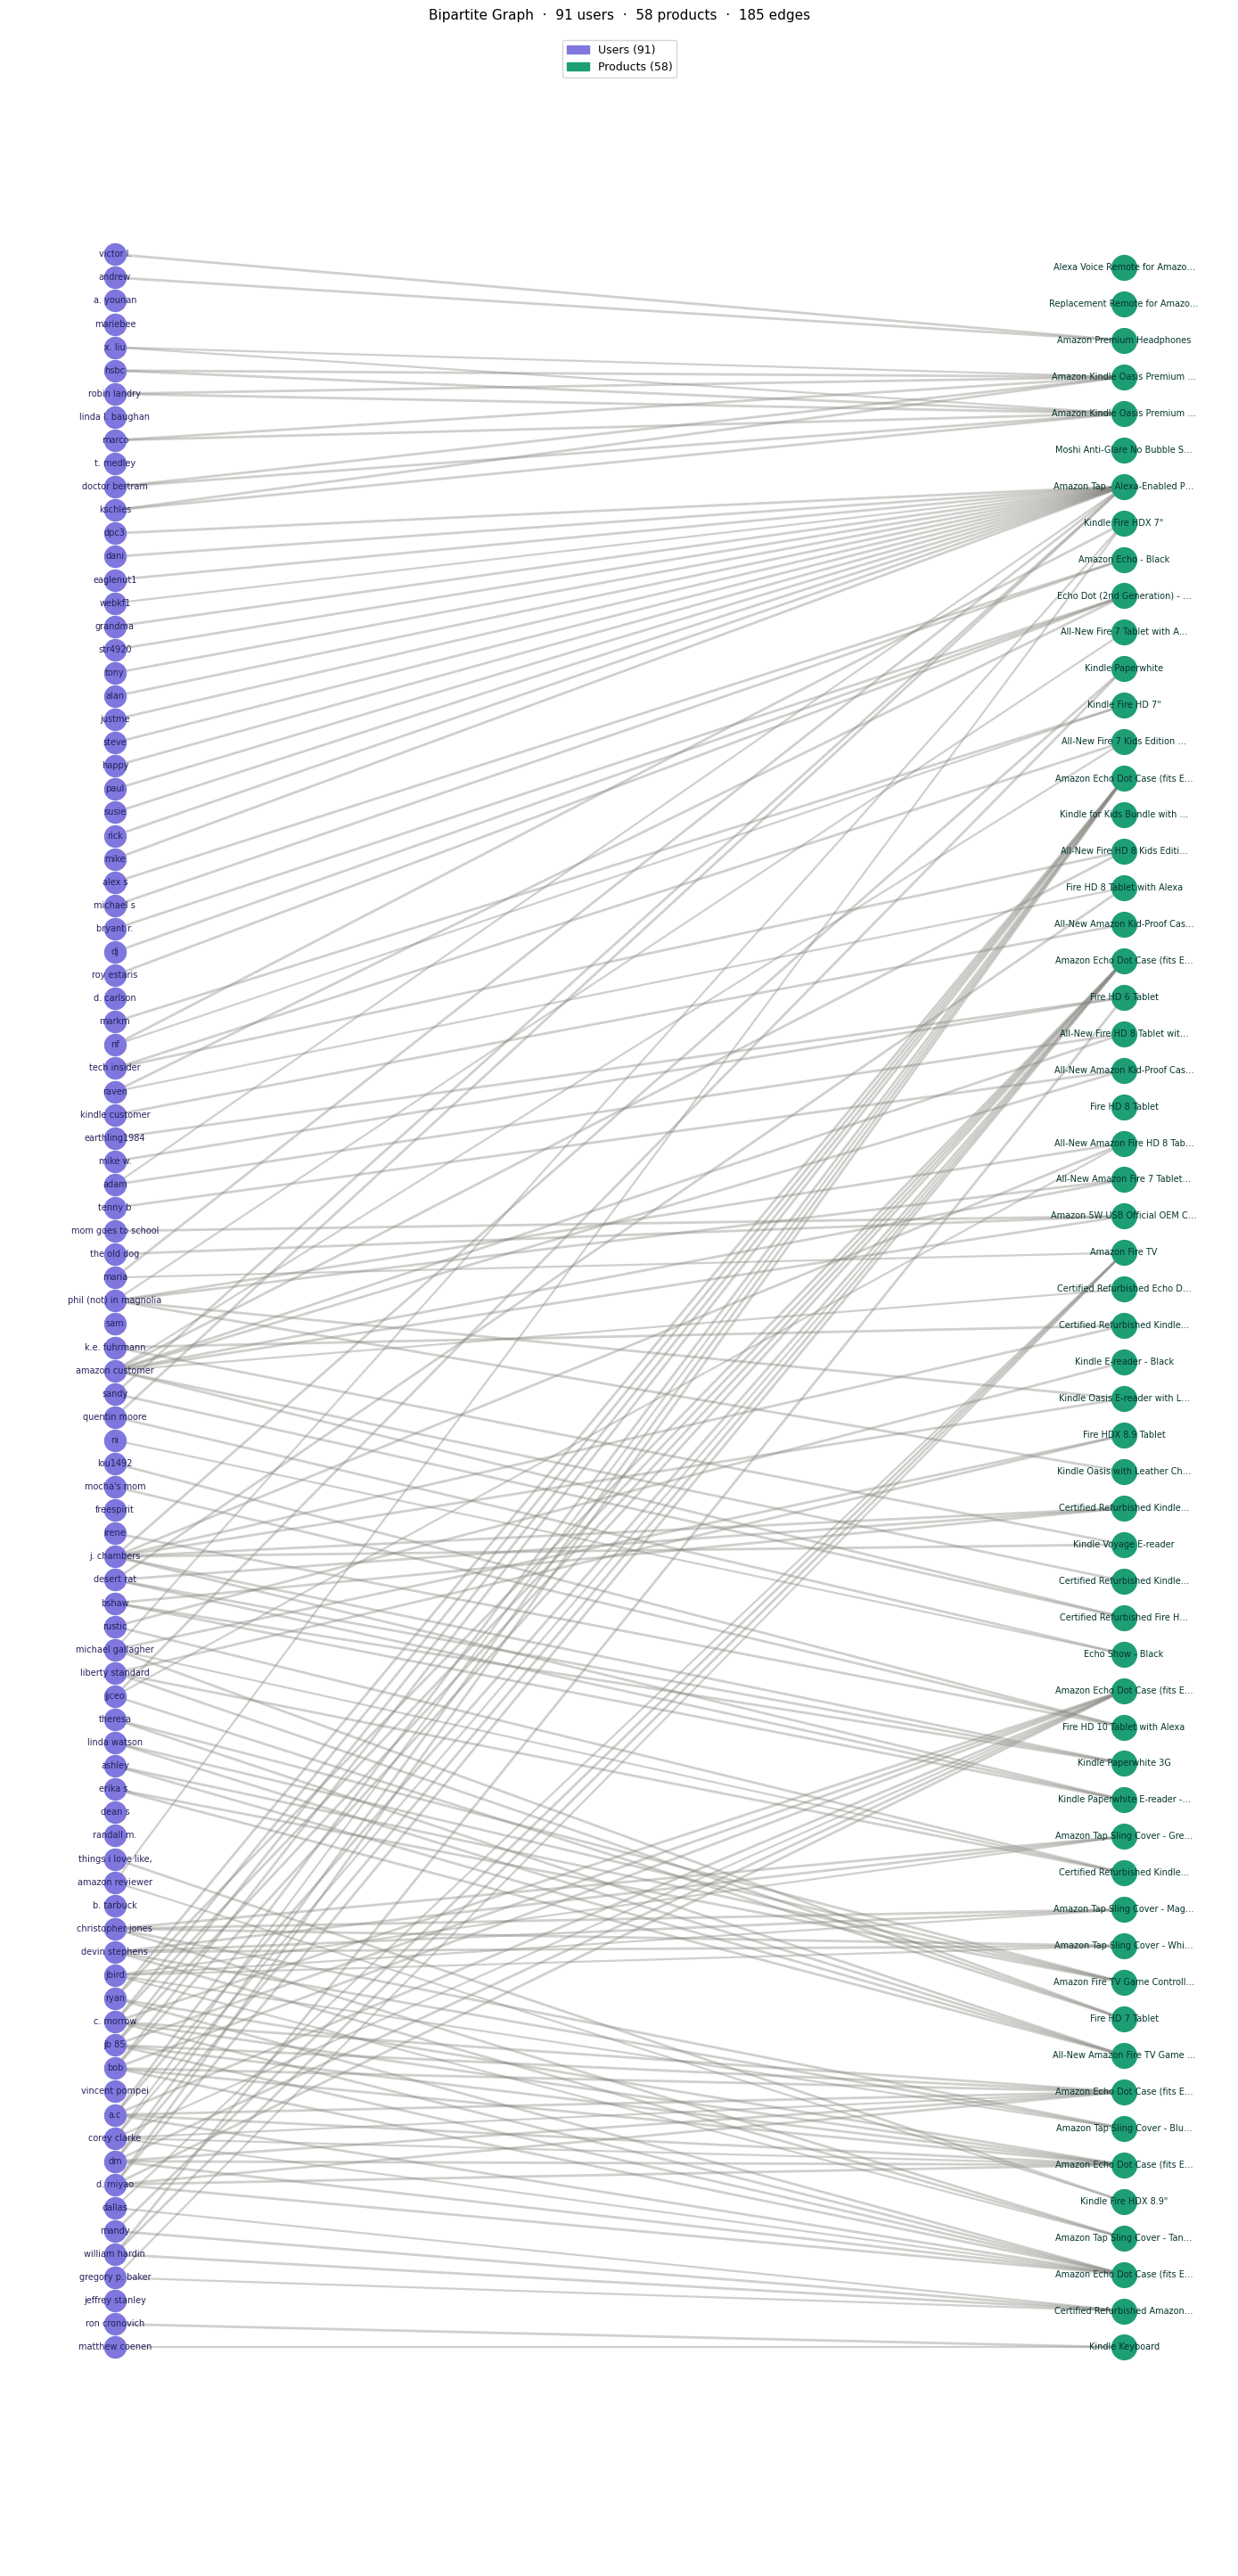

[saved] recsys_output/bipartite_graph.png


In [33]:
"""
Bipartite Graph Visualizer
Run after recommendation_system.py has built and saved the graph.
"""

import pickle
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

OUTPUT_DIR = Path("recsys_output")

# ── Load saved graph ───────────────────────────────────────────────────────────
with open(OUTPUT_DIR / "bipartite_graph.pkl", "rb") as f:
    B = pickle.load(f)

# ── Separate node types ────────────────────────────────────────────────────────
user_nodes    = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 0]
product_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 1]

# ── Layout: users on left, products on right ───────────────────────────────────
pos = {}
for i, u in enumerate(user_nodes):
    pos[u] = (0, i)
for i, p in enumerate(product_nodes):
    pos[p] = (2, i * len(user_nodes) / max(len(product_nodes), 1))

# ── Edge weights for thickness ─────────────────────────────────────────────────
edges      = list(B.edges(data=True))
edge_list  = [(u, v) for u, v, _ in edges]
edge_widths = [d.get("weight", 1) * 0.4 for _, _, d in edges]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(8, len(product_nodes) * 0.5)))

nx.draw_networkx_nodes(B, pos,
    nodelist   = user_nodes,
    node_color = "#7F77DD",
    node_size  = 300,
    ax         = ax)

nx.draw_networkx_nodes(B, pos,
    nodelist   = product_nodes,
    node_color = "#1D9E75",
    node_size  = 400,
    ax         = ax)

nx.draw_networkx_edges(B, pos,
    edgelist  = edge_list,
    width     = edge_widths,
    alpha     = 0.4,
    edge_color= "#888780",
    ax        = ax)

# Truncate long product names for readability
labels = {}
for n in B.nodes():
    labels[n] = n[:28] + "…" if len(n) > 28 else n

nx.draw_networkx_labels(B, pos,
    labels    = {n: labels[n] for n in user_nodes},
    font_size = 7,
    font_color= "#26215C",
    ax        = ax)

nx.draw_networkx_labels(B, pos,
    labels    = {n: labels[n] for n in product_nodes},
    font_size = 7,
    font_color= "#04342C",
    ax        = ax)

# ── Legend + stats ─────────────────────────────────────────────────────────────
ax.legend(handles=[
    mpatches.Patch(color="#7F77DD", label=f"Users ({len(user_nodes)})"),
    mpatches.Patch(color="#1D9E75", label=f"Products ({len(product_nodes)})"),
], loc="upper center", fontsize=9)

ax.set_title(
    f"Bipartite Graph  ·  {len(user_nodes)} users  ·  {len(product_nodes)} products  ·  {B.number_of_edges()} edges",
    fontsize=11, pad=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bipartite_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[saved] {OUTPUT_DIR}/bipartite_graph.png")